# Phase 5: Evaluation (hypothesis tests)

**What the brief asks for:** at least three hypothesis tests. At least two must come from {t-test, two-proportion Z-test, F-test/ANOVA, chi-square}, and one must be an A/B-style comparison of naturally occurring groups. For each: state H0 and H1, report the real test statistic and p-value, say what the p-value does *not* mean, and note that the groups were not randomized.

**My four tests**

| # | Test | Question | Counts as |
|---|---|---|---|
| 1 | Welch t-test | Do high-spending countries have a different average **dropout** than low-spending ones? | A/B-style comparison of natural groups |
| 2 | Two-proportion Z-test | Is the **share of countries with high primary enrolment** different between high- and low-spending countries? | two-proportion Z |
| 3 | One-way ANOVA (F-test) | Does average **secondary enrolment** differ across low, middle and high spenders? | F-test/ANOVA |
| 4 | Chi-square test of independence | Are spending level (three bands) and high primary enrolment **independent**? | chi-square |

## The most important design decision: what is one "observation"?

In the join table, one row is a country in one year. The same country appears up to 50 times with very similar values, so those rows are **not independent**. A test treats every row as new evidence, so it would claim far more certainty than we have. 

So the tests use **one row per country**: each country's average over the years it has data. That gives about 200 independent units. The price is a smaller sample, so the tests have less power. That is the honest trade.

## How the groups are built
- **Income group of a country** = the group it was in for most years.
- **High-spending country** = average spending above the median of countries *in its own income group*. Low = at or below it. This compares each country with similar-income peers, so the comparison is not just rich against poor.
- **Spending bands** = low / middle / high thirds of spending, again within income group.
- **High primary enrolment** = average gross primary enrolment of at least 90%.

## Reading a p-value 
The p-value is the chance of seeing a difference at least this large **if the null hypothesis were true**, that is, if spending and the outcome were unrelated in the population we are sampling.

It is **not**: the probability that the null hypothesis is true; the probability the result is a fluke; the size or importance of the effect; or proof of cause. A small p means "unlikely under no relationship", nothing more. A large p means "the data are consistent with no relationship", not "there is no relationship".

**The groups were not randomized.** Nobody assigned countries to high or low spending. Countries differ in many other ways (stability, aid, geography, governance), so any difference could come from those instead of spending.

Significance level: **α = 0.05**, two-sided throughout. With four tests, the chance that at least one is "significant" by luck is higher than 5%, so I also show the stricter Bonferroni threshold 0.05 / 4 = 0.0125.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

joined = pd.read_csv("C:/Users/kevin/capstone_kevina/data/cleaned/joined.csv")
assert joined.shape[0] == 10562, "joined.csv is not the table from the join notebook"

def mode_(s):
    return s.mode().iloc[0] if s.notna().any() else np.nan

# one row per country: average over the years the country has data
ctry = (joined.groupby("code")
              .agg(country=("country", "first"),
                   spend=("spend_pct_gdp", "mean"),
                   primary=("enr_primary_gross", "mean"),
                   secondary=("enr_secondary_gross", "mean"),
                   dropout=("dropout_proxy", "mean"),
                   income=("income_group", mode_))
              .dropna(subset=["spend", "income"])
              .reset_index())

median_in_group = ctry.groupby("income")["spend"].transform("median")
ctry["spend_group"] = np.where(ctry["spend"] > median_in_group, "high", "low")

tert = ctry.groupby("income")["spend"].transform(lambda s: pd.qcut(s, 3, labels=["low", "middle", "high"]).astype(str))
ctry["spend_band"] = pd.Categorical(tert, categories=["low", "middle", "high"], ordered=True)

ctry["high_primary"] = (ctry["primary"] >= 90).astype("Int8").where(ctry["primary"].notna())

print("countries in the analysis:", len(ctry))
print(ctry["income"].value_counts().to_dict())
print(ctry["spend_group"].value_counts().to_dict())
ctry.head()

countries in the analysis: 203
{'High': 61, 'Lower middle': 57, 'Low': 46, 'Upper middle': 39}
{'low': 103, 'high': 100}


,code,country,spend,primary,secondary,dropout,income,spend_group,spend_band,high_primary
0,ABW,Aruba,5.123659,112.176398,109.096256,7.951069,High,high,high,1
1,AFG,Afghanistan,3.604786,62.553182,31.001678,24.433121,Low,high,middle,0
2,AGO,Angola,3.064097,97.912867,18.860905,70.407183,Lower middle,low,low,1
3,ALB,Albania,3.274369,103.345500,86.448580,7.781213,Lower middle,low,low,1
4,AND,Andorra,2.669555,91.466214,88.584537,31.209668,High,low,low,1


**Checkpoint:** about 203 countries, split roughly 100 high and 103 low. Income groups: High 61, Lower middle 57, Low 46, Upper middle 39. Each of the four tests uses the countries that have the needed measure, so the group sizes differ a little between tests.

A country with no income classification, or with no spending data at all, is left out. 

## Test 1: Welch t-test (A/B-style comparison): dropout

- **H0:** high- and low-spending countries have the same mean dropout proxy.
- **H1:** the means differ (two-sided).
- **Outcome:** `dropout` = average of `100 - persistence to last grade` (WDI). **Groups:** high vs low spending (OWID spending, within World Bank income group).
- **Why Welch:** it does not assume the two groups have equal variance, and the group sizes (about 95 each) are large enough for the t-test to be reliable.

high spending: n = 93, mean dropout = 16.9
low spending : n = 99, mean dropout = 21.9
difference (high - low) = -4.98 points, 95% CI [-10.13, 0.16]
Welch t = -1.912, df = 173.9, p = 0.0575, Cohen's d = -0.27
robustness, Mann-Whitney U (no normality assumption): p = 0.2986


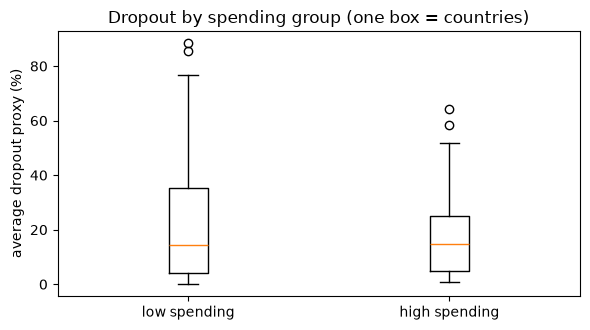

In [2]:
results = []          # every test adds a row here for the summary table in section 5

def welch(df, outcome, group="spend_group", hi="high", lo="low"):
    a = df.loc[df[group] == hi, outcome].dropna()
    b = df.loc[df[group] == lo, outcome].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    va, vb = a.var(ddof=1) / len(a), b.var(ddof=1) / len(b)
    se = np.sqrt(va + vb)
    dof = (va + vb) ** 2 / (va ** 2 / (len(a) - 1) + vb ** 2 / (len(b) - 1))
    diff = a.mean() - b.mean()
    ci = diff + np.array([-1, 1]) * stats.t.ppf(0.975, dof) * se
    pooled_sd = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return dict(n_high=len(a), n_low=len(b), mean_high=a.mean(), mean_low=b.mean(), diff=diff,
                ci_low=ci[0], ci_high=ci[1], t=t, dof=dof, p=p, cohens_d=diff / pooled_sd, a=a, b=b)

r1 = welch(ctry, "dropout")
print(f"high spending: n = {r1['n_high']}, mean dropout = {r1['mean_high']:.1f}")
print(f"low spending : n = {r1['n_low']}, mean dropout = {r1['mean_low']:.1f}")
print(f"difference (high - low) = {r1['diff']:.2f} points, 95% CI [{r1['ci_low']:.2f}, {r1['ci_high']:.2f}]")
print(f"Welch t = {r1['t']:.3f}, df = {r1['dof']:.1f}, p = {r1['p']:.4f}, Cohen's d = {r1['cohens_d']:.2f}")
print(f"robustness, Mann-Whitney U (no normality assumption): p = {stats.mannwhitneyu(r1['a'], r1['b']).pvalue:.4f}")

results.append(dict(test="1. Welch t-test", outcome="dropout proxy, high vs low spending",
                    statistic=f"t = {r1['t']:.2f}", p=r1["p"], effect=f"{r1['diff']:+.1f} points (d = {r1['cohens_d']:.2f})"))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.boxplot([r1["b"], r1["a"]])
ax.set_xticklabels(["low spending", "high spending"])
ax.set(ylabel="average dropout proxy (%)", title="Dropout by spending group (one box = countries)")
plt.tight_layout(); plt.show()

**Draft reading (check against your output).** High-spending countries have about 5 points lower average dropout (roughly 17% against 22%). The p-value is just above 0.05, so at the 5% level we **cannot reject H0**. The confidence interval for the difference runs from about -10 to just above zero, so the data are consistent with anything from "no difference" to "a fairly large difference". The Mann-Whitney test, which does not depend on the shape of the data, gives a larger p, so this result is the least solid of the four.

**Outcome** A p-value of 0.057 means the evidence is not strong enough to rule out chance, not that the effect is absent. The direction matches the hypothesis. The honest sentence is: *suggestive, not conclusive*.

## Test 2: Two-proportion Z-test: high primary enrolment

- **H0:** the share of countries with high primary enrolment (gross, at least 90%) is the same among high- and low-spending countries.
- **H1:** the shares differ (two-sided).
- **Why this test:** the outcome is yes/no, so we compare two proportions.

In [3]:
def two_prop(x1, n1, x0, n0):
    p1, p0 = x1 / n1, x0 / n0
    pooled = (x1 + x0) / (n1 + n0)
    se0 = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n0))     # standard error under H0 (pooled)
    z = (p1 - p0) / se0
    p = 2 * stats.norm.sf(abs(z))
    se1 = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)       # unpooled, for the confidence interval
    ci = (p1 - p0) + np.array([-1, 1]) * 1.96 * se1
    return p1, p0, z, p, ci

d2 = ctry.dropna(subset=["high_primary"])
g = d2.groupby("spend_group")["high_primary"].agg(["sum", "count"]).astype(int)
display(g)

x1, n1 = g.loc["high", "sum"], g.loc["high", "count"]
x0, n0 = g.loc["low", "sum"], g.loc["low", "count"]
p1, p0, z2, pv2, ci2 = two_prop(x1, n1, x0, n0)
print(f"high spending: {x1}/{n1} = {p1:.3f}")
print(f"low spending : {x0}/{n0} = {p0:.3f}")
print(f"difference = {(p1 - p0) * 100:+.1f} percentage points, 95% CI [{ci2[0] * 100:.1f}, {ci2[1] * 100:.1f}]")
print(f"z = {z2:.3f}, p = {pv2:.4f}")
print("check, expected counts all >= 10:", bool(min(n1 * (x1 + x0) / (n1 + n0), n1 * (1 - (x1 + x0) / (n1 + n0)),
                                                    n0 * (x1 + x0) / (n1 + n0), n0 * (1 - (x1 + x0) / (n1 + n0))) >= 10))

results.append(dict(test="2. Two-proportion Z", outcome="share with primary enrolment >= 90%",
                    statistic=f"z = {z2:.2f}", p=pv2, effect=f"{(p1 - p0) * 100:+.1f} percentage points"))

,sum,count
spend_group,,
high,86,99
low,77,103


high spending: 86/99 = 0.869
low spending : 77/103 = 0.748
difference = +12.1 percentage points, 95% CI [1.4, 22.8]
z = 2.180, p = 0.0292
check, expected counts all >= 10: True


**Draft reading.** About 87% of high-spending countries have high primary enrolment against about 75% of low-spending ones: a gap of roughly 12 percentage points, **p about 0.03**. At the 5% level we **reject H0**: a gap this large would be unusual if spending and enrolment were unrelated. The interval for the gap is wide (about 1 to 23 points), so we know the sign better than the size.

This is the same comparison as Phase 4's probabilities (90% vs 82%), but on one row per country instead of one row per country-year. The gap is bigger here because averaging over years removes noise.

## Test 3: One-way ANOVA (F-test): secondary enrolment across three spending bands

- **H0:** low, middle and high spenders have the same mean secondary enrolment.
- **H1:** at least one band's mean differs.
- **Outcome:** `secondary` = average gross secondary enrolment (WDI). **Groups:** spending thirds within income group (OWID spending).
- **Why ANOVA:** three groups means three means to compare at once. Running three separate t-tests would inflate the false-positive rate.

A significant F only says *some* band differs, not which. For a pattern, look at the means.

         n  mean secondary enrolment    sd
low     69                      67.4  32.1
middle  67                      72.3  30.7
high    66                      80.1  32.4

F(2, 199) = 2.740, p = 0.0670, eta-squared = 0.027
assumption check, Levene (equal variances): p = 0.808
robustness, Kruskal-Wallis (no normality assumption): p = 0.0513


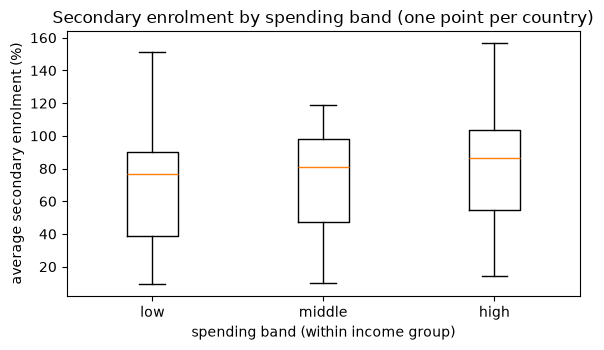

In [4]:
d3 = ctry.dropna(subset=["secondary"])
groups = [d3.loc[d3["spend_band"] == b, "secondary"] for b in ["low", "middle", "high"]]

F, p3 = stats.f_oneway(*groups)
grand = d3["secondary"].mean()
ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
ss_total = ((d3["secondary"] - grand) ** 2).sum()
eta2 = ss_between / ss_total

print(pd.DataFrame({"n": [len(g) for g in groups], "mean secondary enrolment": [round(g.mean(), 1) for g in groups],
                    "sd": [round(g.std(), 1) for g in groups]}, index=["low", "middle", "high"]))
print(f"\nF({len(groups) - 1}, {len(d3) - len(groups)}) = {F:.3f}, p = {p3:.4f}, eta-squared = {eta2:.3f}")
print(f"assumption check, Levene (equal variances): p = {stats.levene(*groups).pvalue:.3f}")
print(f"robustness, Kruskal-Wallis (no normality assumption): p = {stats.kruskal(*groups).pvalue:.4f}")

results.append(dict(test="3. ANOVA (F)", outcome="secondary enrolment across 3 spending bands",
                    statistic=f"F = {F:.2f}", p=p3, effect=f"eta-squared = {eta2:.3f}"))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.boxplot(groups)
ax.set_xticklabels(["low", "middle", "high"])
ax.set(xlabel="spending band (within income group)", ylabel="average secondary enrolment (%)",
       title="Secondary enrolment by spending band (one point per country)")
plt.tight_layout(); plt.show()

**Draft reading.** Mean secondary enrolment rises across the bands (roughly 67%, 72%, 80%). The F-test gives **p about 0.07**, so at 5% we **cannot reject H0**. The Kruskal-Wallis test is close to 0.05. Effect size (eta-squared about 0.03) says spending band explains only about 3% of the variation between countries in secondary enrolment: small.

Note the contrast with Phase 4, where the secondary correlation was the strongest (r about 0.32). Different tests answer different questions: a correlation uses every country-year and the whole spending range, while this test compares only three coarse groups of about 200 countries, so it has less power. Not every test has to agree; report each one as it came out.

## Test 4: Chi-square test of independence: spending band and high primary enrolment

- **H0:** spending band and high primary enrolment are independent (the share of countries with high enrolment is the same in all three bands).
- **H1:** they are not independent.
- **Why this test:** both variables are categories. It extends Test 2 from two groups to three.

In [5]:
d4 = ctry.dropna(subset=["high_primary"]).copy()
ct = pd.crosstab(d4["spend_band"], d4["high_primary"])
ct.columns = ["enrolment < 90%", "enrolment >= 90%"]
display(ct)
display((ct.div(ct.sum(axis=1), axis=0) * 100).round(1).add_suffix(" (row %)"))

chi2, p4, dof4, expected = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.to_numpy().sum() * (min(ct.shape) - 1)))
print(f"chi-square({dof4}) = {chi2:.3f}, p = {p4:.4f}, Cramer's V = {cramers_v:.3f}")
print("assumption check, smallest expected count:", round(expected.min(), 1), "(should be >= 5)")

results.append(dict(test="4. Chi-square", outcome="spending band x high primary enrolment",
                    statistic=f"chi2({dof4}) = {chi2:.2f}", p=p4, effect=f"Cramer's V = {cramers_v:.2f}"))

,enrolment < 90%,enrolment >= 90%
spend_band,,
low,16,53
middle,17,50
high,6,60


,enrolment < 90% (row %),enrolment >= 90% (row %)
spend_band,,
low,23.2,76.8
middle,25.4,74.6
high,9.1,90.9


chi-square(2) = 6.671, p = 0.0356, Cramer's V = 0.182
assumption check, smallest expected count: 12.7 (should be >= 5)


**Draft reading.** The share with high primary enrolment is about 77% in the low band, 75% in the middle and 91% in the high band. **p about 0.04**, so at 5% we **reject H0**. The gain is concentrated in the top band rather than increasing steadily. Cramer's V (about 0.18) is a small-to-moderate association.

This test is not independent of Test 2: both use the same countries and the same outcome. Do not count them as two separate pieces of evidence.

## 5. All four tests together

In [6]:
summary = pd.DataFrame(results)
summary["p-value"] = summary["p"].round(4)
summary["reject H0 at 0.05?"] = np.where(summary["p"] < 0.05, "yes", "no")
summary["reject at Bonferroni 0.0125?"] = np.where(summary["p"] < 0.05 / len(summary), "yes", "no")
summary[["test", "outcome", "statistic", "p-value", "effect", "reject H0 at 0.05?", "reject at Bonferroni 0.0125?"]]

,test,outcome,statistic,p-value,effect,reject H0 at 0.05?,reject at Bonferroni 0.0125?
0,1. Welch t-test,"dropout proxy, high vs low spending",t = -1.91,0.0575,-5.0 points (d = -0.27),no,no
1,2. Two-proportion Z,share with primary enrolment >= 90%,z = 2.18,0.0292,+12.1 percentage points,yes,no
2,3. ANOVA (F),secondary enrolment across 3 spending bands,F = 2.74,0.0670,eta-squared = 0.027,no,no
3,4. Chi-square,spending band x high primary enrolment,chi2(2) = 6.67,0.0356,Cramer's V = 0.18,yes,no


**Draft reading.**
- **Two of four** tests are significant at 5% (the proportion test and the chi-square test, both about primary enrolment). The t-test (dropout) and ANOVA (secondary) are borderline, just above 0.05.
- **None** pass the stricter Bonferroni threshold. With four tests, one 'significant' result at 5% is partly expected by chance.
- **All four** point in the same direction: more spending goes with higher enrolment and lower dropout. Consistent direction counts for something even when individual p-values are modest.
- **Effects are small to moderate.** This agrees with Phase 4 (correlations of 0.2 to 0.3).

**A fair summary for the write-up:** *the evidence that higher-spending countries have better enrolment and dropout outcomes is consistent in direction but modest in strength, and cannot be treated as proof.*

## 6. Two sensitivity checks

### (a) What happens if we ignore that rows repeat countries?

Repeat Test 2 on the country-year rows (the `high_spend` and `high_enrol_primary` columns from the join). The row-level test has about 3,300 'observations' but only about 200 countries, so it overstates the evidence.

In [7]:
rows = joined.dropna(subset=["high_spend", "high_enrol_primary"])
g = rows.groupby("high_spend")["high_enrol_primary"].agg(["sum", "count"]).astype(int)
a1, an1 = g.loc[1, "sum"], g.loc[1, "count"]
a0, an0 = g.loc[0, "sum"], g.loc[0, "count"]
q1, q0, zz, pp, cc = two_prop(a1, an1, a0, an0)
print(f"country-YEAR rows: {len(rows):,} rows from {rows['code'].nunique()} countries")
print(f"high spending {q1:.3f} vs low {q0:.3f}, gap {(q1 - q0) * 100:+.1f} points, z = {zz:.2f}, p = {pp:.2e}")
print(f"country-level test (section 2): z = {z2:.2f}, p = {pv2:.4f}")

country-YEAR rows: 3,345 rows from 199 countries
high spending 0.902 vs low 0.822, gap +8.0 points, z = 6.73, p = 1.73e-11
country-level test (section 2): z = 2.18, p = 0.0292


**Draft reading.** The row-level p-value is astronomically small (around 1e-11, z above 6), while the country-level one is about 0.03. Same data, same question. The first is wrong, because it treats 3,300 repeated rows as 3,300 independent pieces of evidence. This is the reason the tests above use one row per country. Mention it in the write-up: it shows you know the p-value depends on the independence assumption.

### (b) Where is the effect? Low-income countries only (exploratory)

Phase 4 suggested the relationship is strongest in low-income countries. Test it, but label it **post hoc**: I looked at this subgroup *because* Phase 4 pointed to it, which makes a 'significant' result less trustworthy. With only about 23 countries per group, use Fisher's exact test instead of the Z approximation.

In [8]:
low_inc = d2[d2["income"] == "Low"]
tab = pd.crosstab(low_inc["spend_group"], low_inc["high_primary"]).reindex(index=["high", "low"])
tab.columns = ["enrolment < 90%", "enrolment >= 90%"]
display(tab)
_, p_fisher = stats.fisher_exact(tab.to_numpy())
odds = ((tab.loc["high", "enrolment >= 90%"] / tab.loc["high", "enrolment < 90%"]) /
        (tab.loc["low", "enrolment >= 90%"] / tab.loc["low", "enrolment < 90%"]))
sh = tab.loc["high", "enrolment >= 90%"] / tab.loc["high"].sum()
sl = tab.loc["low", "enrolment >= 90%"] / tab.loc["low"].sum()
print(f"low-income countries: high spending {sh:.2f} vs low spending {sl:.2f}")
print(f"Fisher exact p = {p_fisher:.4f}  (the odds of high enrolment are {odds:.1f} times higher for high spenders; n = {tab.to_numpy().sum()} countries)")

# for context: the same comparison in the other income groups
rows_ = []
for grp in ["Low", "Lower middle", "Upper middle", "High"]:
    s = d2[d2["income"] == grp]
    t_ = pd.crosstab(s["spend_group"], s["high_primary"]).reindex(index=["high", "low"], columns=[0, 1], fill_value=0)
    rows_.append({"income group": grp, "high-spend share": round(t_.loc["high", 1] / t_.loc["high"].sum(), 2),
                  "low-spend share": round(t_.loc["low", 1] / t_.loc["low"].sum(), 2),
                  "countries": int(t_.to_numpy().sum()), "Fisher p": round(stats.fisher_exact(t_.to_numpy())[1], 3)})
pd.DataFrame(rows_)

,enrolment < 90%,enrolment >= 90%
spend_group,,
high,10,13
low,18,5


low-income countries: high spending 0.57 vs low spending 0.22
Fisher exact p = 0.0331  (the odds of high enrolment are 4.7 times higher for high spenders; n = 46 countries)


,income group,high-spend share,low-spend share,countries,Fisher p
0,Low,0.57,0.22,46,0.033
1,Lower middle,0.89,0.83,56,0.707
2,Upper middle,1.00,0.85,39,0.231
3,High,1.00,1.00,61,1.000


**Draft reading.** Among low-income countries about 57% of the high spenders have high primary enrolment against 22% of the low spenders (Fisher p about 0.03). That is the largest gap of any group, and it matches Phase 4. But it is one of four subgroups, found after looking, with small samples. After correcting for four subgroups the threshold is 0.0125, which this does not pass.

In the High income group every country has high enrolment in both halves (100% against 100%), so no test is possible there. Spending cannot make a difference to something already at its maximum.

Treat this as a **lead for future work**, not as a finding.